
# `Материалы кафедры ММП факультета ВМК МГУ. Введение в глубокое обучение.`

# `Занятие 15. Рекуррентные нейронные сети`

## `Занятие провёл: Овсиенко Олеся (@Olesya_Ovsienko)`

## `Материалы составили: Овсиенко Олеся (@Olesya_Ovsienko), Алексеев Илья (@voorhs)`

### `Москва, Весенний семестр 2026`

Источники:

- [Советуем так же ознамиться с материалами предыдущих лет](https://github.com/mmp-practicum-team/mmp_practicum_spring_2024/blob/main/Seminars/Seminar%2006/%D0%A0%D0%B5%D0%BA%D1%83%D1%80%D1%80%D0%B5%D0%BD%D1%82%D0%BD%D1%8B%D0%B5%20%D0%9D%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D0%B5%20%D0%A1%D0%B5%D1%82%D0%B8.ipynb)

- **Simple Recurrent Networks (Elman)**: [Elman J. L., 1991](https://link.springer.com/content/pdf/10.1007/BF00114844.pdf), примерно 2 тысячи цитирований
- **Vanishing/Exploding Gradients in RNN**: [Pascanu R. et al., 2013](https://arxiv.org/abs/1211.5063), примерно 9 тысяч цитирований
- **LSTM**: [Hochreiter S., Schmidhuber J., 1997](https://www.bioinf.jku.at/publications/older/2604.pdf), примерно 146 тысяч цитирований
- **GRU**: [Cho K. et al., 2014](https://arxiv.org/abs/1406.1078), примерно 40 тысяч цитирований
- **Batch Normalization**: [Ioffe S., Szegedy C., 2015](https://arxiv.org/abs/1502.03167), примерно 67 тысяч цитирований
- **Layer Normalization**: [Ba J. L., Kiros J. R., Hinton G. E., 2016](https://arxiv.org/abs/1607.06450), примерно 18 тысяч цитирований
- **Instance Normalization**: [Ulyanov D., Vedaldi A., Lempitsky V., 2016](https://arxiv.org/abs/1607.08022), примерно 5 тысяч цитирований
- **Bahdanau Attention**: [Bahdanau D., Cho K., Bengio Y., 2014](https://arxiv.org/abs/1409.0473), примерно 43 тысячи цитирований

Реализации:

- **RNN (PyTorch)**: [https://pytorch.org/docs/stable/generated/torch.nn.RNN.html](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html)
- **Gradient clipping (PyTorch)**: [https://docs.pytorch.org/docs/stable/generated/torch.nn.utils.clip_grad_norm_.html]
- **BatchNorm1d (PyTorch)**: [https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html](https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html)
- **LayerNorm (PyTorch)**: [https://pytorch.org/docs/stable/generated/torch.nn.LayerNorm.html](https://pytorch.org/docs/stable/generated/torch.nn.LayerNorm.html)
- **GRU (PyTorch)**: [https://pytorch.org/docs/stable/generated/torch.nn.GRU.html](https://pytorch.org/docs/stable/generated/torch.nn.GRU.html)
- **LSTM (PyTorch)**: [https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)

Это занятие будет посвящено рекуррентным нейронным сетям (RNN) и их эволюции от простой ячейки до современных gated-моделей. Мы начнём с ограничений статических эмбеддингов (word2vec), разберём базовую RNN-ячейку, проблему vanishing/exploding gradients при Backpropagation Through Time и практические решения: gradient clipping, Layer Normalization (почему BatchNorm не подходит для текстов), правильную токенизацию. Далее подробно рассмотрим LSTM и GRU &ndash; как внутренние гейты и skip-connections решают проблему длинных зависимостей. Обсудим ключевые задачи последовательного моделирования: классификация текстов, causal language modeling (next-token prediction как первый пример self-supervised learning), распознавание именованных сущностей (BIO-разметка), машинный перевод с encoder-decoder архитектурой. Затронем модификации (bidirectional RNN, stacked layers, residual connections) и введём механизм внимания (Bahdanau attention). Мы опираемся на ключевые статьи по каждой теме, а количество цитирований указано для того, чтобы дать представление о масштабе области и вовлеченности научного сообщества, а не для прямого сравнения статей друг с другом.

---

## Вспомним w2v


На прошлой неделе вы познакомились с языковой моделью word2vec. Это модель получения эмбедингов для отдельных токенов. Её можно применять как для слов, так и для текстов. Чтобы получить эмбединг текста с помощью word2vec, достаточно усреднить эмбединги токенов, входящих в текст. Схематически это выглядит следующим образом:


Такую модель можно даже дообучать, чтобы адаптировать word2vec эмбединги под конкретную задачу. Однако у данной модели есть существенный недостаток. Рассмотрим пример предложения: “Робин съел лук”. Слово “лук” &ndash; известный пример омонимии. Смысл этого токена нельзя понять без контекста, в котором он встретился. В данном случае, скорее всего, это овощ. Но эмбединг слова “лук”, полученный методом word2vec, будет передавать информацию обо всех значениях этого токена, а не только ту её узкую и более точную часть, которая относится к текущему контексту.


Таким образом, у такого подхода есть принципиальный недостаток: эмбеддинг каждого слова статичен и не зависит от контекста предложения.
Именно поэтому для задач, где важен порядок слов и их взаимное влияние, были разработаны рекуррентные нейронные сети (RNN).

## RNN Cell

Введем модель, которую назовем рекуррентной ячейкой:



Рекуррентная ячейка имеет два входа $h,x$ и два выхода $h',y$:
$$
h'=g_h(Wx+Uh+b_h),\quad
y=g_y(Vh'+b_y),
$$
где $W, U, V$ &ndash; матрицы весов (размеры зависят от размерностей векторов $x$ и $h$), $b_h, b_y$ &ndash; векторы смещений (bias), $g_h(\cdot),g_y(\cdot)$ &ndash; функции активации. 

По сути, рекуррентная ячейка &ndash; это обычный полносвязный слой с нелинейностью, но с дополнительным потоком «вправо»: предыдущее скрытое состояние $  h  $ «смешивается» с текущим входом $  x  $ через линейное преобразование. Поэтому её записывают компактно:
$$
h',y=\text{RNNCell}(h,x).
$$

<font color='orange'>**Вопрос:**</font> Мы определили новый слой RNNCell. Как он отличается от классического линейного? Как можно применять RNNCell для обработки последовательностей и благодаря чему?

#### Ответ:

RNNCell добавляет вектор контекста, который обновляется в зависимости от последовательности данных. Благодаря этому механизму мы можем применять один слой много раз к последовательности, тем самым переиспользуя веса.


## RNN (1991)

[Elman J. L., 1991](https://link.springer.com/content/pdf/10.1007/BF00114844.pdf), примерно 2 тысячи цитирований


Применим рекуррентную ячейку к целому тексту путем обработки всех токенов одной и той же рекуррентной ячейкой последовательно:


$$
h_t,y_t=\text{RNNCell}(h_{t-1},e(w_t)),\quad t=\overline{1,T}.
$$
Векторы $h_t$ будем называть скрытыми состояниями. Вектор $h_0$ инициализируется нулевым. Совершая проход по предложению, рекуррентная сеть сохраняет в $h$ информацию о всех токенах. А именно, в $h_t$ “примешана” информация о всех токенах $w_1,\ldots,w_t$.

Самое главное, что в результате такого прогона получается последовательность $y_1,\ldots,y_T$ &ndash; эти векторы можно воспринимать как репрезентации токенов $w_1,\ldots, w_T$, обогащенные контекстной информацией.

<font color='orange'>**Вопрос:**</font> Вам нужно обработать текст длинной N токенов. Размерность каждого токена равна 128. Скрытая размерность 64. Сколько обучаемых параметров будет в RNN? Сколько параметров будет в линейном слое, который обрабатывает все токены сразу?


#### Ответ:

RNN будет иметь столько же параметров сколько и одна RNNCell. RNNCell содержит:
1) 2 вектора смещения размера 64
2) W размера 128 * 64
3) U, V размера 64 * 64

Итого: 2 * 64 + 64*128 + 2 * 64 * 64 =16512 

В случае линейного слоя мы бы получили:

1) матрица весов размера 128 * N * 64
2) вектор смещений 64

Итого: 8192 * N + 64

Таким образом, при N $\ge$ 3 по количеству параметров RNN эффективнее, то есть менее подверженно переобучению.


### Для каких задач нужны рекуррентные нейронный сети?
Если коротко, то для любых задач, где обрабатываются последовательности. В частности:
* Моделирование естественных языков.
* Анализ и генерация звука.
* Предсказание или анализ временных рядов.

### Основные модели работы с последовательностями
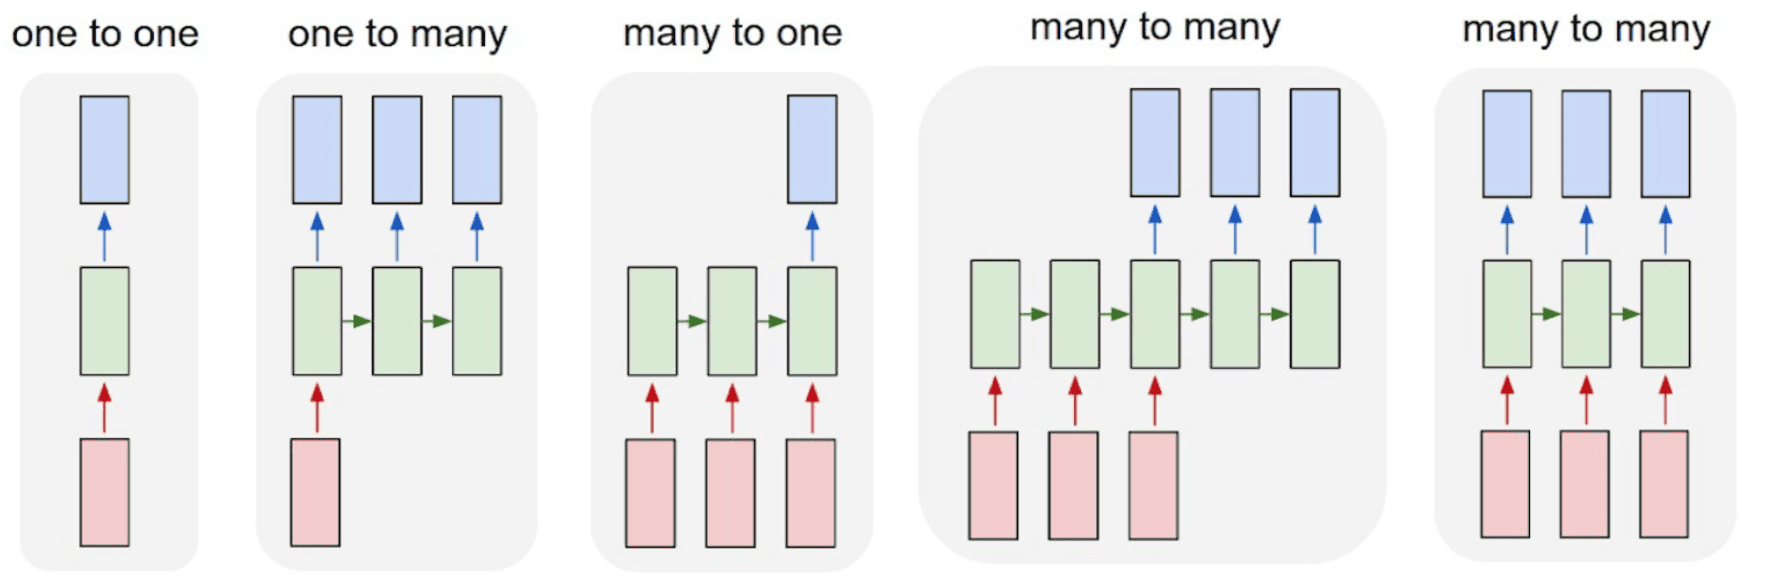

* One-to-one: На вход один объект и на выходе тоже (вырожденный случай) [например, классификация картинок]
* One-to-many: На вход подается один объект, на выходе последовательность объектов [например, создание подписей к картинкам (image captioning)]
* Many-to-one: На вход подается последовательность объектов, на выходе один объект [например, классификация текстов или видео]
* Many-to-many: На входе и выходе последовательности нефиксированной длины [например, машинный перевод, распознавание именованных сущностей]

## Backpropagation Through Time
Итак, мы предложили новую архитектуру. Осталось понять, как такое учить? Человечество все ещё не придумало ничего лучше градиентной оптимизации, поэтому использовать мы будем именно её. Осталось понять, как считать градиенты через рекуррентность. Для этого существует Backpropagation Through Time.

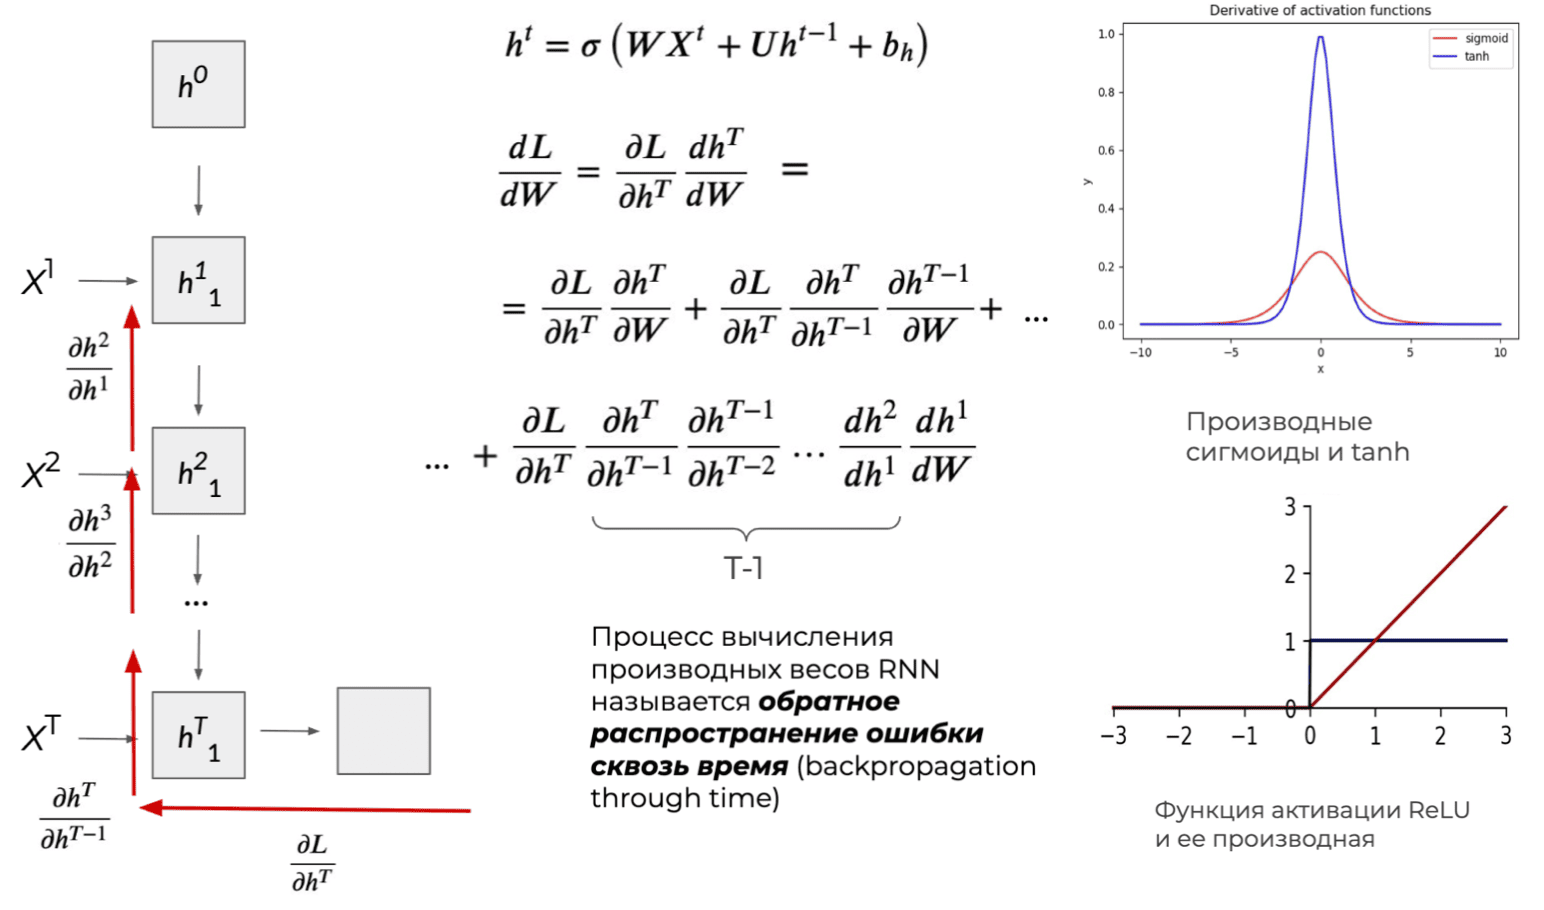

Из формулы ясно, что всего два фактора влияют на порядок значения градиента &ndash; веса и функции активации. В RNN взрыв / затухание градиента связан с тем, что повторное произведение похожих якобианов ведёт к экспоненциальному росту / убыванию модуля градиента.

Как показано в работе [Pascanu et al., 2013](https://arxiv.org/abs/1211.5063), примерно 12 тысяч цитирований, если все собственные значения матрицы больше 1, то градиент «взрывается», а если меньше 1 &ndash; «затухает». Причём рано или поздно происходит поляризация, т.е. момент, когда большинство матриц принимает либо слишком большие, либо слишком малые значения.

Другой факт заключается в том, что большинство функций активаций имеют ограниченные сверху 1.0 производные. Поэтому их перемножение ведёт к затуханию градиента. В итоге это приводит к тому, что более ранние слои не обучаются (получают градиент около 0), из-за чего не происходит обучение остальных слоёв.

## Gradient clipping 

Что делать если градиенты взрываются?

В рекуррентных сетях при обратном распространении ошибки через длинную последовательность градиенты иногда становятся гигантскими. Обновления весов превращаются в хаос, сеть буквально «взрывается» и перестаёт обучаться.

Самый простой и очень эффективный способ решить эту проблему &ndash; gradient clipping, то есть искусственное ограничение градиентов по норме: если норма градиента превышает заданный порог $\theta$, мы заменяем его на обрезанную версию.

Обозначим через $g$ вектор градиентов функции потерь по всем весам модели. Тогда в оптимизатор подаётся вектор $\hat{g}$, который вычисляется по правилу:

$$
\hat{g} =
\begin{cases}
g, & \text{если } \|g\|_2 \leq \theta, \\
\theta \dfrac{g}{\|g\|_2}, & \text{если } \|g\|_2 > \theta,
\end{cases}
$$

где $\theta$ &ndash; гиперпараметр (порог обрезки).

Таким образом мы полностью предотвращаем взрыв градиентов. При этом градиенты становятся гораздо более стабильными: их дисперсия заметно уменьшается, а значит обучение сходится быстрее и надёжнее.


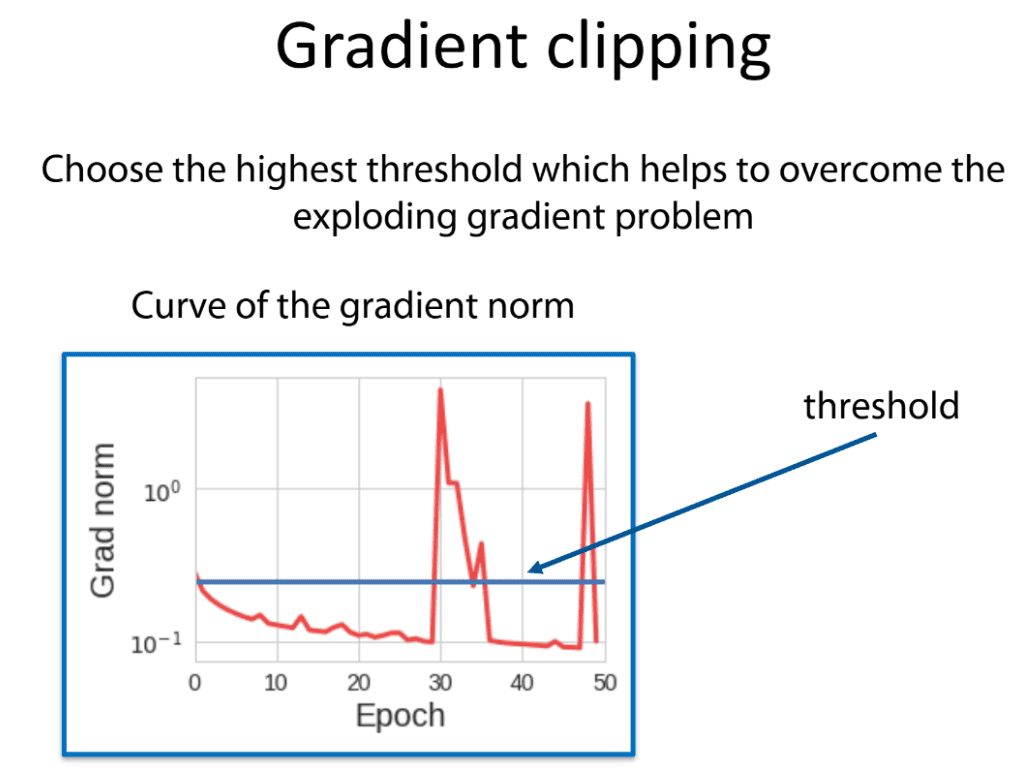

Gradient clipping &ndash; это стандартный приём, который почти всегда используют при обучении любых RNN.

## Регуляризация в RNN

Обучать RNN довольно тяжело на длинных последовательностях из-за угасания и взрыва градиентов. Для борьбы с этим существует стандартный набор трюков: нормализация, дропаут (с этим вы хорошо познакомитесь в домашке), правильная токенезация. Каждый из методов имеет свои нюансы и особенности, так как мы работаем с данными переменной длины и переиспользуем веса между ячейками. Рассмотрим знакомую вам нормализацию и как её особенности.

### LayerNorm

[Ba J. L., Kiros J. R., Hinton G. E., 2016](https://arxiv.org/abs/1607.06450), примерно 18 тысяч цитирований

<font color='orange'>**Вопрос:**</font> Один из популярных способов борьбы с затуханием градиентов &ndash; Batch Normalization.
Но в задачах с текстами он почти никогда не используется. Как вы думаете, почему?

#### Ответ:

Потому что тексты имеют переменную длину, батчи обычно маленькие, а ещё мы вынуждены использовать паддинг. В результате статистики, которые считает BatchNorm, получаются очень шумными и нестабильными.

Давайте посмотрим, как именно это происходит.
Вход у нас &ndash; тензор (batch_size, sequence_length, hidden_size). BatchNorm считает среднее и дисперсию по всему батчу и по всей длине последовательности одновременно:

$$
\mu_{h} = \frac{1}{BT} \sum_{i,t=1}^{B,T} x_{ith} \text{ , } \sigma_{h}^2 = \frac{1}{BT} \sum_{i,t=1}^{B,T} (x_{ith} - \mu_{h})^2 \text{ , } y_{ith} = \gamma_h\frac{x_{ith} - \mu_{h}}{\sqrt{\sigma_{h}^2 + \epsilon}}+\delta_h
$$

Когда в одном батче лежат тексты разной длины (а короткие заполнены паддингом), эти средние и дисперсии становятся бессмысленными. Нормализация «ломается», и вместо помощи мы получаем дополнительные проблемы.
Именно поэтому для последовательных моделей придумали Layer Normalization. Она считает статистики по размерности признаков для каждого токена отдельно:
$$
\mu_{it} = \frac{1}{H} \sum_{h=1}^H x_{ith} \text{ , } \sigma_{it}^2 = \frac{1}{H} \sum_{h=1}^H (x_{ith} - \mu_{it})^2 \text{ , } y_{ith} = \gamma_h\frac{x_{ith} - \mu_{it}}{\sqrt{\sigma_{it}^2 + \epsilon}}+\delta_h
$$

Именно поэтому LayerNorm стал стандартным выбором во всех современных моделях для текста &ndash; от RNN до трансформеров.


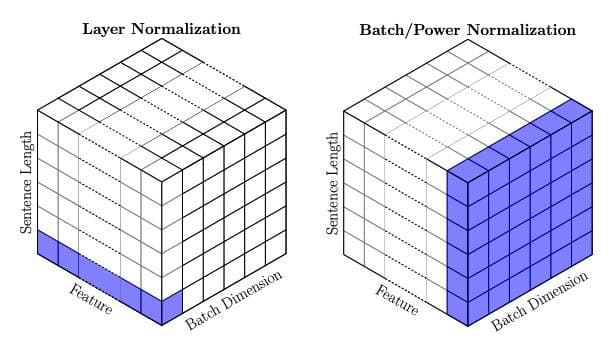

[Источник](http://proceedings.mlr.press/v119/shen20e/shen20e.pdf)

### Токенизация

Очевидно, что чем длиннее входная последовательность, тем сложнее решать задачи с ней. На длину последовательности влияет способ токенизации текста. Рассмотрим два крайних случая

**Токен = символ.**

- плюс: маленький вокабулярий (=число поддерживаемых символов) => нужно относительно мало выходов классификатора 
- минус: вход относительно длинный

**Токен = слово.**

- плюс: вход относительно короткий
- минус: огромный вокабулярий который все равно не охватит все слова языка

Балансом между этими крайними случаями является так называемые BPE-токенизация, о которой было рассказано ранее в курсе.

## Gated models

LSTM (Long Short-Term Memory) и GRU (Gated Recurrent Unit) &ndash; это разновидности рекуррентных нейронных сетей, которые внутри себя используют специальные механизмы-гейты, чтобы селективно пропускать, забывать или усиливать информацию. Gated models были придуманы для решения проблемы затухающих градиентов.

### LSTM (1997)
[Hochreiter S., Schmidhuber J., 1997](https://www.bioinf.jku.at/publications/older/2604.pdf), примерно 146 тысяч цитирований

Используется два вектора внутреннего состояния: $h_t$ &ndash; ближайший контекст (короткая память), $c_t$ &ndash; контекст всего предложения (долгая память).

Вычисляются следующие величины:

- forget gate: $f_t = \sigma(h_{t-1}W^f + x_t U^f+b_f)\in(0,1)$ &ndash; регулирует, какие сигналы (компоненты $С_t$) нужно ослабить (механизм стирания из памяти)
- input gate: $i_t = \sigma(h_{t-1}W^i + x_t U^i+b_i)\in(0,1)$ &ndash; регулирует, нужно ли добавить что-то в долговременную память
- output gate: $o_t = \sigma(h_{t-1}W^o + x_t U^o+b_o)\in(0,1)$ &ndash; регулирует, насколько долговременную память $С_t$ уместно использовать прямо сейчас
- candidate memory: $\tilde{C}_t=\tanh(h_{t-1} W^С + x_t U^С+b_С)$

Из них формируются $h_t$ и $С_t$:
$$
С_t = f_t \odot С_{t-1} +  i_t \odot  \tilde{C}_t,\quad
h_t =  o_t \odot \tanh(С_t),
$$
где $\odot$ &ndash; поэлементное умножение.

Вектор $h_t$ используется одновременно и как выход, и как внутреннее состояние.

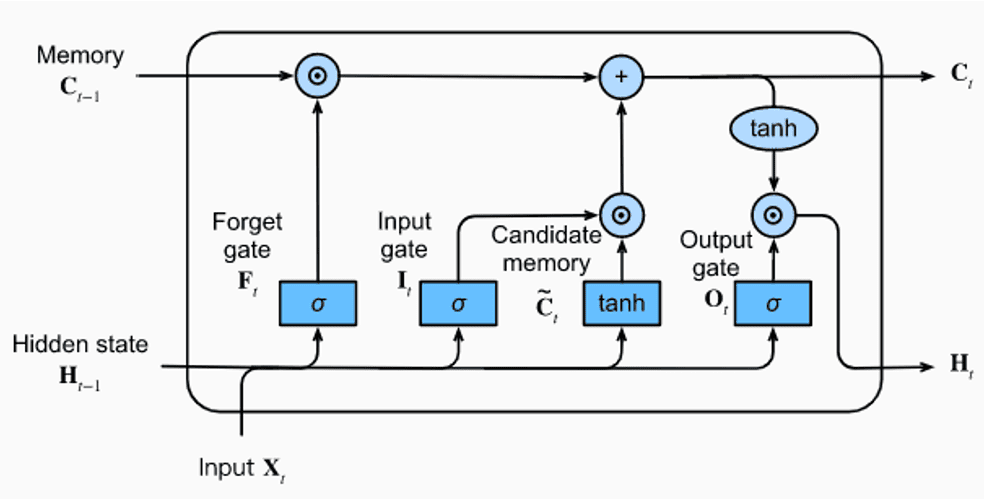

[Источник](https://link.springer.com/article/10.1007/s44163-025-00565-6)

Заметим, что в LSTM решена проблема затухания градиента (см. выражение для обновления $C_t$):

$$
\frac{\partial C_t}{\partial C_{t-1}} = \frac{\partial C_t}{\partial f_t} \frac{\partial f_t}{\partial h_{t-1}} \frac{\partial h_{t-1}}{\partial C_{t-1}} + \frac{\partial C_t}{\partial i_t} \frac{\partial i_t}{\partial h_{t-1}} \frac{\partial h_{t-1}}{\partial C_{t-1}} + \frac{\partial C_t}{\partial \tilde{C}_t} \frac{\partial \tilde{C}_t}{\partial h_{t-1}} \frac{\partial h_{t-1}}{\partial C_{t-1}} + \frac{\partial C_t}{\partial C_{t-1}}
$$

$$
\Rightarrow{\frac{\partial C_t}{\partial C_{t-1}} 
= C_{t-1} \sigma'(\cdot) W^f * o_{t-1} \tanh'(C_{t-1}) + \tilde{C}_t \sigma'(\cdot) W^i * o_{t-1} \tanh'(C_{t-1}) + }
$$

$$
+ i_t \tanh'(\cdot) W^C * o_{t-1} \tanh'(C_{t-1}) + f_t
$$

$$
\Rightarrow{\frac{\partial C_t}{\partial C_{t-1}} = \text{(3 небольших слагаемых, так содержат в себе } \sigma' \text{ и/или } \tanh' \text{) } + f_t}
$$

Таким образом, когда сеть хочет сохранить информацию надолго, она учится держать forget-gate близким к 1. Тогда при распространении градиента через сотни шагов мы получаем произведение $\prod f_j \approx 1$, и градиент почти не затухает.

<font color='orange'>**Вопрос:**</font> На что похоже использование вектора $C_t$? Какой механизм он реализует?


#### Ответ:

Вектор долговременной памяти $С_t$ &ndash; это внутренний skip-connection внутри LSTM-ячейки (подобно residual connection в ResNet позволяет градиенту свободно течь через десятки слоёв). Именно поэтому LSTM способна обучаться на достаточно длинных последовательностях, где обычная RNN полностью «забывает» начало.

### GRU (2014)

[Cho K. et al., 2014](https://arxiv.org/abs/1406.1078), примерно 40 тысяч цитирований

GRU &ndash; это облегчённая версия LSTM. В отличие от LSTM, здесь нет отдельной долгосрочной памяти $C_t$. Всё хранится в одном векторе состояния $h_t$. 

Вычисления:

- reset gate: $r_t=\sigma(W^rh_{t-1}+U^r x_t+b^r)\in(0,1)$ &ndash; механизм стирания из памяти
- update gate: $u_t=\sigma(W^uh_{t-1}+U^ux_t+b^u)\in(0,1)$ &ndash; механизм записи в память (комбинирует в себе input и output gate одновременно)
- candidate hidden state: $\tilde{h}_t=\tanh(W^h(r_t\odot h_{t-1})+U^hx_t+b^h)$
- hidden state: $h_t=u_t\odot h_{t-1}+(1-u_t)\odot \tilde{h}_t$


[Источник](https://www.researchgate.net/figure/Calculation-of-the-forward-hidden-layers_fig2_348828975)

## Применение и обучение RNN



Необходимо разобраться, как обучать рекуррентную сеть таким образом, чтобы в контекст $h$ и в обновленные репрезентации $y$ записывалась информация, полезная для решения конкретных задач NLP.

### Классификация


Чтобы обучить рекуррентную сеть на задачу классификации, можно применить усреднение обновленных репрезентаций:



В данной схеме все операции дифференцируемы, поэтому обучая классификационную голову на кросс-энтропийный лосс, мы получим градиенты и для рекуррентного блока. Заметим, что везде применяется одна и та же рекуррентная ячейка. Это сближает рекуррентные сети со свёрточными в том смысле, что обе архитектуры основаны на идее применения одних и тех же (разделённых) параметров к разным частям входа.

Помимо этого для решения задачи классификации можно также брать только последний токен, так как в нём содержится весь контекст.

### Causal Language Modeling
Или задача предсказания следующего токена. Это генеративная задача. Сначала объясним, как это должно работать, и только потом, как это обучать.

На вход такой задаче приходит начало предложения, которое называют затравкой (prompt). Задача продолжить это предложение. Допустим, в качестве затравки используется “Однажды я съездил в Питер и со мной случилось следующее:”, тогда задача модели сгенерировать текст, который может выдумать, что с ней случилось в Питере.

Рекуррентные сети справляются с такими задачами путем авторегрессионного инференса:



На этой схеме классификатор везде один и тот же и он выдает вероятности по всем токенам в словаре. Это вероятности каждого токена быть следующим в предложении. Предсказав токен $e_{T+1}$, его можно подать на вход рекуррентной ячейке (и соответственно классификатору), которая предскажет токен $e_{T+2}$. И так далее.

Термин “авторегрессия” взят из задачи предсказания временных рядов, где тоже часто используют свои предыдущие предсказания для получения всё новых и новых.

Остается вопрос: как обучить рекуррентную сеть для работы в авторегрессионном режиме? Для этого достаточно собрать большой корпус текстов. Один обучающий пример формируется следующим образом. Допустим у нас есть текст $w_1,\ldots,w_T$. Тогда

1. прогоним через RNN текст $w_1,\ldots,w_{T-1}$ и получим $y_1,\ldots,y_{T-1}$
2. пропустим игреки через классификатор и получим логиты
3. используем кросс-энтропийный лосс, где истинными метками будут  $w_2,\ldots,w_T$ 

Описанный выше способ обучения &ndash; это и есть задача next token prediction (предсказание следующего токена).
Её главное преимущество в том, что никакой ручной разметки не требуется вообще. Достаточно просто взять большой корпус сырых текстов. Мы сами себе «выдумываем» метки: сдвигаем последовательность на один токен вправо.
Именно поэтому next token prediction считается первым примером самообучения (self-supervised learning) в обработке текста &ndash; модель учится без участия человека, просто предсказывая, что будет дальше.

В следующих занятиях будет рассказано больше практических соображений о том, как формировать обучающую выборку и батчи для обучения языковой модели для генерации текстов.

### Распознавание именованных сущностей
Именованными сущностями (named entity) называют адрес, имя, время и прочее. Обычно они представляют некоторую информацию, которую нужно извлечь из текста. Попытаемся пойти от простого к сложному. Допустим, мы хотим извлекать человеческие имена вроде Илья, Петя, Гриша. Самый простой способ &ndash; это бинарная классификация каждого токена на предмет того, является ли он человеческим именем:




Чтобы обучить такую модель, достаточно собрать корпус текстов и сделать разметку для каждого токена.

Рассмотрим пример сложнее: распознавание адресов вроде “ул. Строителей, дом 9”. Главная сложность в том, что  именованная сущность распростерлась на несколько токенов, каждый из которых не является именованной сущностью. В таких случаях вместо бинарной классификации используют классификацию на три класса: beginning, inside, outside (так называемая BIO-разметка). Каждый токен мы классифицируем на три класса:

- B: первый токен именованной сущности
- I: токен, относящийся к именованной сущности, но не являющийся первым
- O: токен, не относящийся к именованной сущности

Рассмотрим пример ещё сложнее: распознавание и человеческих имён, и адресов. Сложность в том, что нужно уметь извлекать разные сущности с помощью одной модели. Решение простое: заведем BIO классы для каждой сущности.


### Перевод

RNN можно применять для перевода с языка на язык. Для этого используются так называемые автокодровщики, с идеей которых вы можете быть знакомы, если помните как решались img-to-img задачи. Сейчас мы будем решать задачу text-to-text.

Допустим, мы хотим обучить модель для перевода с английского на французский. На инференсе должно работать в следующем режиме:

- прогоним эмбеддинги английского текста $e(w_1),\ldots,e(w_T)$ через RNN и получим $h_T$ &ndash; скрытое состояние RNN после эмбеддинга токена $w_T$
- возьмем вторую RNN сеть, которая будет генерировать перевод в авторегрессионном режиме
- дли этого подадим ей в качестве затравки служебный токен `[BOS]` (означает beginning of sequence), и в качестве начального вектора контекста $h_T$
- генерируем перевод до тех пор, пока языковая голова не предскажет токен `[EOS]` (означает end of sequence)

Чтобы обучить такую модель достаточно применить тот же рецепт, что и для обучения causal languge model.

Первую RNN сеть (которая кодирует $e(w_1),\ldots,e(w_T)$ в вектор $h_T$) называют кодировщиком. Вторую RNN сеть (которая из $h_T$ генерирует перевод в авторегрессионном режиме) называют декодировщиком.

## Модификации RNN

Очевидный недостаток обсуждаемой модели в том, что рекуррентное движение происходит только слева направо. Последние токены предложения “видят” первые, но не наоборот. Чтобы исправить это, достаточно добавить вторую RNN сеть, которая будет совершать свой путь в обратном направлении. Тогда в качестве обновлённой репрезентации токена $x_t$ можно взять $(y_t+\tilde y_t)$, где $y_t$ &ndash; выход из первой сети, а $\tilde y_t$ &ndash; выход из второй.

Благодаря этому каждый токен теперь «видит» весь контекст предложения целиком &ndash; и слева, и справа. Именно поэтому Bidirectional RNN (и особенно BiLSTM / BiGRU) стали стандартным решением в задачах, где важен полный контекст (например, в распознавании именованных сущностей, машинном переводе или классификации текстов).




Второй очевидной модификаций является многослойная RNN сеть. Каждый слой будет выполнять ту же функцию что и в MLP и в свёрточных сетях: генерация все более высокоуровневых и полезных для задачи признаков.




Ещё одна модификация, которая может сработать, это прокидывание остаточных связей между слоями.




## Механизм внимания


[Bahdanau D., Cho K., Bengio Y., 2014](https://arxiv.org/abs/1409.0473), примерно 43 тысячи цитирований

Обратимся к задаче перевода (text-to-text). У предложенного нами решения с помощью RNN есть очевидный недостаток: во время авторегрессионного предсказания перед декодером стоит слишком сложная задача сгенерировать целый текст имея на вход всего лишь супер сжатое представление исходного текста в виде одного вектора. Что если позволить декодеру в каждый момент генерации видеть не только вектор контекста $h$, но и эмбединги исходной последовательности? Тогда декодер смог бы совершать перевод например так, как это делают люди: смотря на конкретную часть исходного текста и подбирая слова для перевода. Такую возможность дает механизм внимания.

Посмотрим внимательно на формулу RNN ячейки:
$$
s_t=g_s(W_1z_t+W_2s_{t-1}+b_s),\quad y_t=g_y(Us_t+b_y).
$$
Активация $y_t$ используется как признаки для предсказания следующего токена $z_{t+1}$. При этом $y_t$ получается только из текущего токена перевода $z_t$ и из вектора контекста $s_{t-1}$. Что если мы модифицируем сумму в скобках:
$$
s_t=g_s(W_1z_t+W_2s_{t-1}+W_3d_t+b_s),\quad d_t=\sum_{i=1}^Th_i\alpha_{it},
$$
где $\alpha_{it}$ &ndash; некоторые веса, характеризующие полезность $i$-го токена исходной последовательности для предсказания $(t+1)$-го токена перевода. Если мы сможем для каждого шага $t$ подбирать нужные веса, получится реализовать умную агрегацию информации из исходной последовательности, которую можно назвать механизмом внимания (токены перевода уделяют разное внимание исходным токенам).

Простейший вариант определения весов $\alpha$ следующий:
$$
\alpha_{it}={\exp(\text{sim}(s_{t-1},h_i))\over\sum_{j=1}^T\exp(\text{sim}(s_{t-1},h_j))},\quad\text{sim}(x,y)=\langle x,y\rangle.
$$


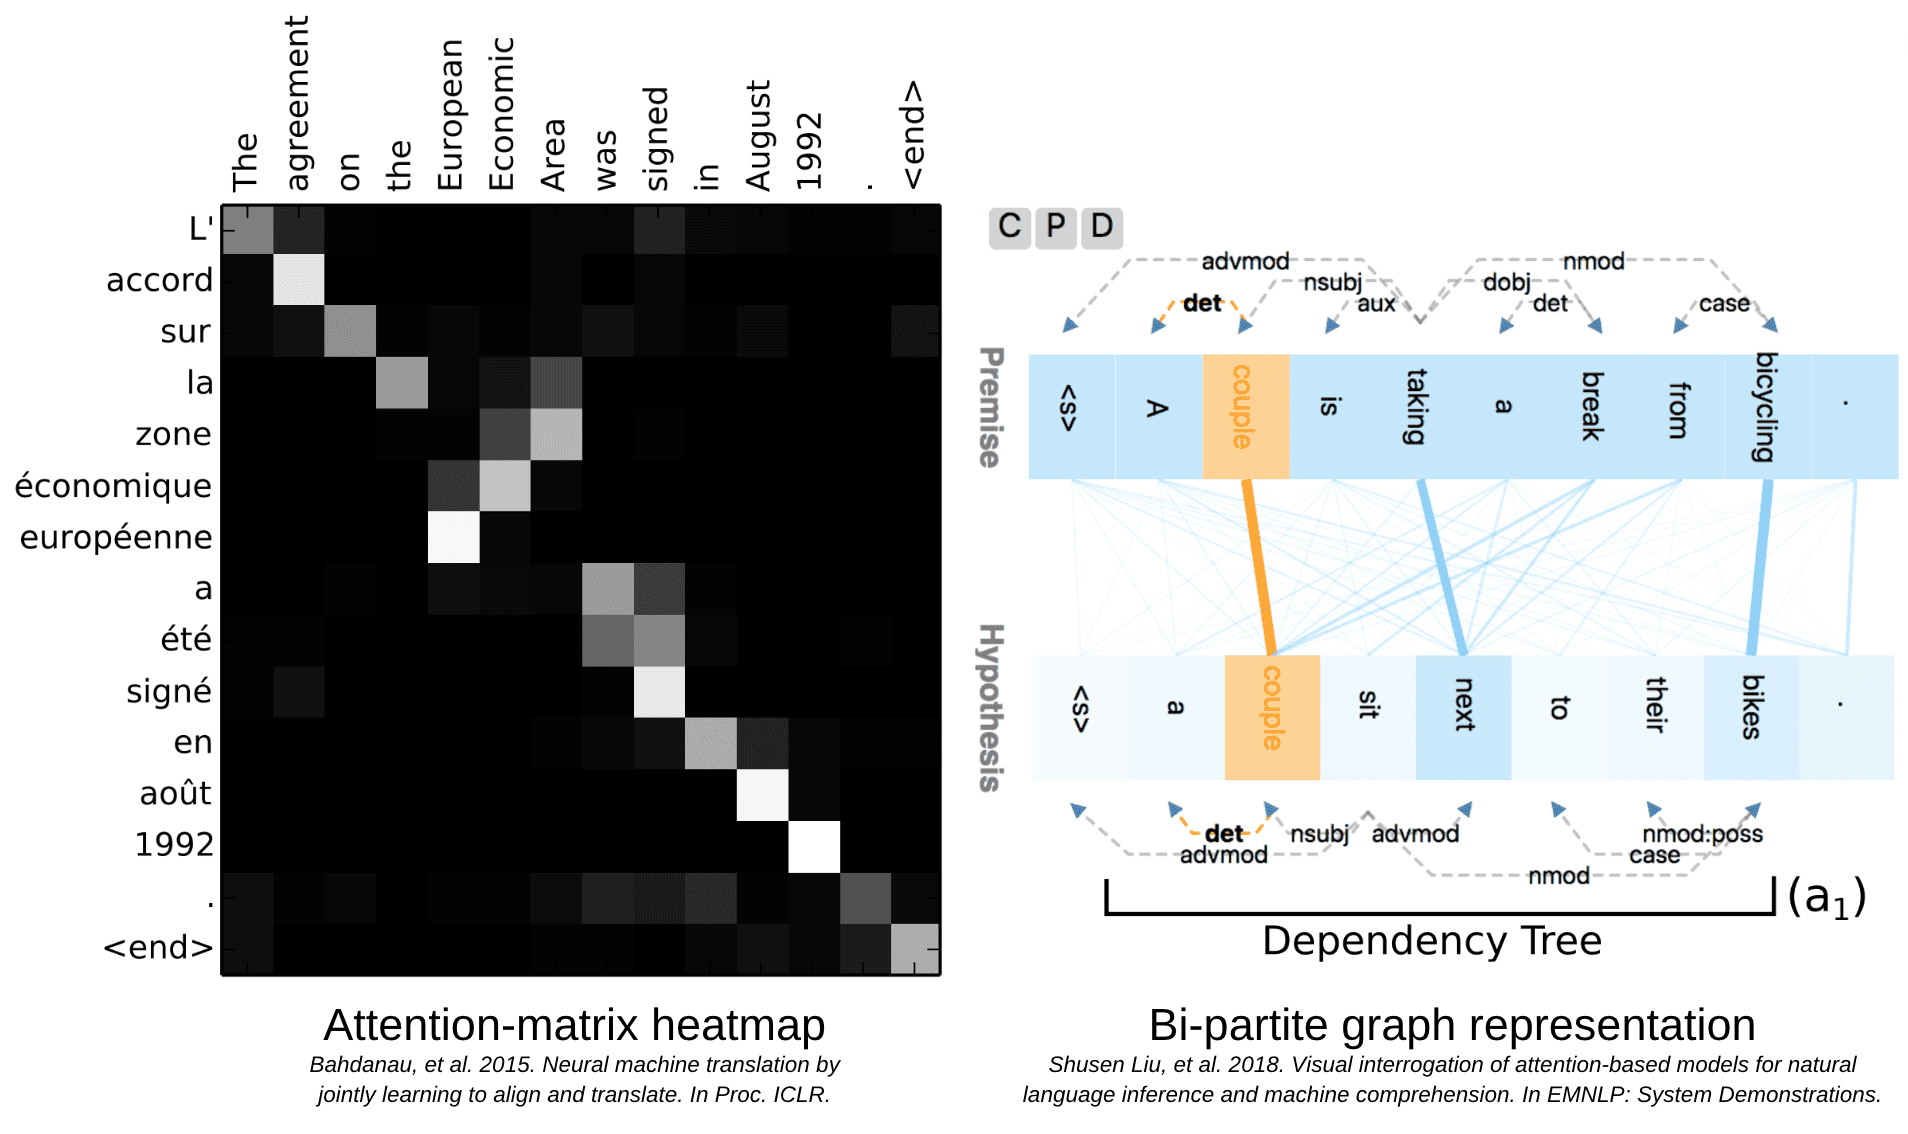

[Источник 1](https://arxiv.org/abs/1409.0473)
[Источник 2](https://aclanthology.org/D18-2007.pdf)

## Заключение

Рекуррентные нейронные сети, включая LSTM и GRU, сыграли важную роль в развитии методов обработки последовательностей и остаются полезным инструментом в ряде задач.

В настоящее время в большинстве задач обработки естественного языка RNN в значительной степени вытеснены трансформерами. Последние обеспечивают более высокое качество и лучше масштабируются, а также значительно менее подвержены проблемам затухания и взрыва градиентов благодаря архитектуре с механизмом внимания и residual-связями.

Тем не менее RNN сохраняют преимущества в следующих сценариях:
- при потоковой обработке данных;
- при ограниченных вычислительных ресурсах;
- когда критичны низкая задержка и малое потребление памяти.

Далее в курсе будет рассмотрена архитектура трансформеров &ndash; современный стандарт для работы с последовательностями. 